# Phase 4: Tree-Based Model Comparison

Goal:
- Compare the baseline logistic regression model with a tree-based model
- Evaluate whether a nonlinear model improves default prediction
- Assess the tradeoff between interpretability and performance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve, confusion_matrix, average_precision_score

In [ ]:
df = pd.read_excel("../data/raw/credit_card_clients_raw.xls", header=1)
df = df.rename(columns={"default payment next month": "default_next_month"})
df = df.drop(columns=["ID"])

target_col = "default_next_month"
X = df.drop(columns=[target_col])
y = df[target_col]

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [7]:
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]
ordinal_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
payment_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
numeric_cols = ["LIMIT_BAL", "AGE"] + bill_cols + payment_cols

In [8]:
log_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("ord", "passthrough", ordinal_cols),
        ("cat", "passthrough", categorical_cols)
    ]
)

In [9]:
log_model = Pipeline([
    ("preprocessing", log_preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [10]:
log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [11]:
log_val_probs = log_model.predict_proba(X_val)[:, 1]
log_test_probs = log_model.predict_proba(X_test)[:, 1]

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

In [13]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [14]:
rf_val_probs = rf_model.predict_proba(X_val)[:, 1]
rf_test_probs = rf_model.predict_proba(X_test)[:, 1]

In [15]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Validation ROC-AUC": [
        roc_auc_score(y_val, log_val_probs),
        roc_auc_score(y_val, rf_val_probs)
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, log_test_probs),
        roc_auc_score(y_test, rf_test_probs)
    ],
    "Validation Avg Precision": [
        average_precision_score(y_val, log_val_probs),
        average_precision_score(y_val, rf_val_probs)
    ],
    "Test Avg Precision": [
        average_precision_score(y_test, log_test_probs),
        average_precision_score(y_test, rf_test_probs)
    ]
})

results

,Model,Validation ROC-AUC,Test ROC-AUC,Validation Avg Precision,Test Avg Precision
0,Logistic Regression,0.712963,0.716912,0.502875,0.494148
1,Random Forest,0.771215,0.777383,0.546930,0.554421


In [16]:
log_test_pred = (log_test_probs >= 0.5).astype(int)
rf_test_pred = (rf_test_probs >= 0.5).astype(int)

print("Logistic Regression Confusion Matrix")
print(confusion_matrix(y_test, log_test_pred))

print("\nRandom Forest Confusion Matrix")
print(confusion_matrix(y_test, rf_test_pred))

Logistic Regression Confusion Matrix
[[3405   99]
 [ 764  232]]

Random Forest Confusion Matrix
[[3318  186]
 [ 634  362]]


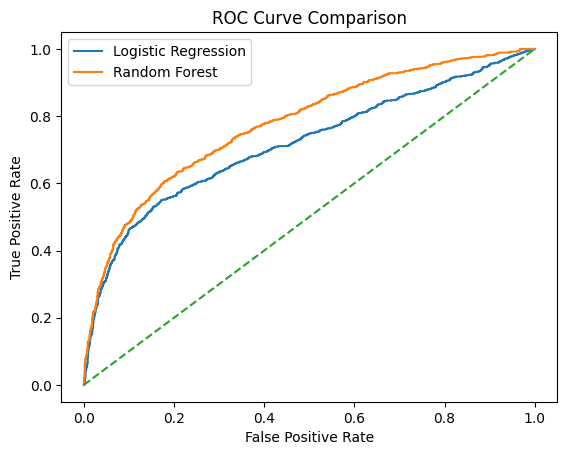

In [17]:
log_fpr, log_tpr, _ = roc_curve(y_test, log_test_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_probs)

plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

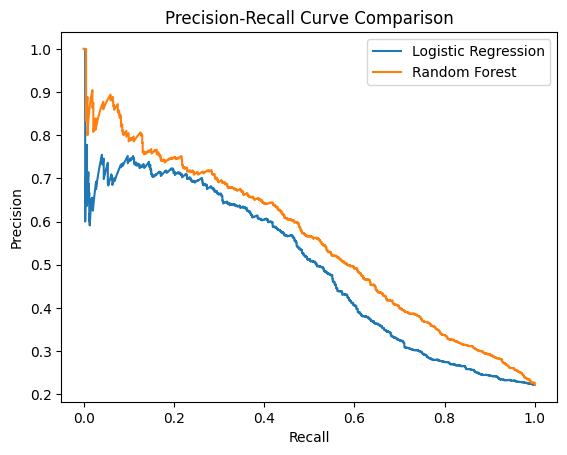

In [18]:
log_precision, log_recall, _ = precision_recall_curve(y_test, log_test_probs)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_test_probs)

plt.plot(log_recall, log_precision, label="Logistic Regression")
plt.plot(rf_recall, rf_precision, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

In [19]:
rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

rf_importance.head(15)

,feature,importance
5,PAY_0,0.163994
6,PAY_2,0.067778
11,BILL_AMT1,0.051763
17,PAY_AMT1,0.047855
0,LIMIT_BAL,0.047606
12,BILL_AMT2,0.046228
18,PAY_AMT2,0.044960
4,AGE,0.044600
13,BILL_AMT3,0.043142
16,BILL_AMT6,0.042548


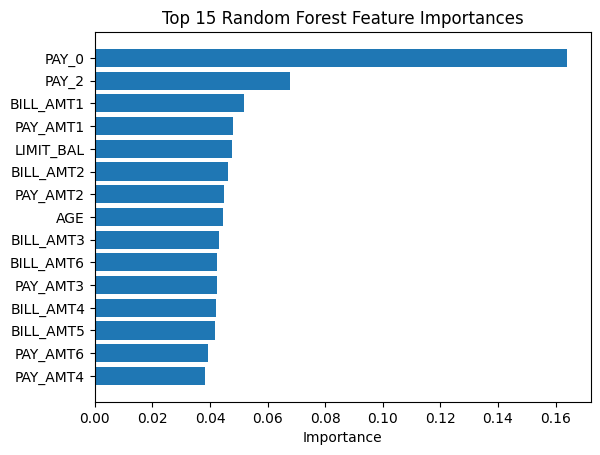

In [20]:
top_features = rf_importance.head(15).sort_values(by="importance")

plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.title("Top 15 Random Forest Feature Importances")
plt.show()

## Model Comparison Interpretation

- Logistic regression provides a strong and interpretable baseline.
- Random forest can capture nonlinear relationships and interactions that logistic regression cannot.
- If random forest shows higher ROC-AUC or average precision, it suggests that nonlinear structure exists in the data.
- If the improvement is small, logistic regression may still be preferable because it is easier to explain and calibrate.
- Repayment history remains the most important feature group across both approaches.

## Phase 4 Summary

- Logistic regression was kept as the baseline probability of default model.
- Random forest was added as a nonlinear benchmark.
- The two models were compared using ROC-AUC and precision-recall metrics.
- Random forest may improve predictive performance, but logistic regression remains more interpretable.
- The next phase will focus on deeper evaluation, threshold analysis, and calibration.